我们将使用类似但更复杂的Fashion-MNIST数据集

In [16]:
%matplotlib inline
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
from d2l import torch as d2l

# d2l.use_svg_display()  # SVG 需要信任，改用 PNG 避免显示问题
%config InlineBackend.figure_format = 'png'  # 使用 PNG 格式输出图像


通过框架中的内置函数将Fashion_MNIST数据集下载并读取到内存中

In [17]:
# 通过ToTensor实例将图像数据从PIL类型转换成32位浮点数格式
#并且除以255使所有像素的数值均在 0-1 之间
trans=transforms.ToTensor()
mnist_train=torchvision.datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
mnist_test=torchvision.datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)
print(len(mnist_train), len(mnist_test))

60000 10000


## 可视化函数

下面定义两个辅助函数：
1. 将数字标签转换为可读的文本类别名称
2. 批量绘制图像网格


In [18]:
# 函数1：返回 Fashion-MNIST 数据集的文本标签
# Fashion-MNIST 共 10 个类别，标签为 0-9 的整数
# 此函数将数字索引映射为人类可读的类别名称
def get_fashion_mnist_labels(labels):
    """输入数字标签列表，返回对应的文本标签列表。"""
    text_labels = [
        't-shirt',   # 0 T恤
        'trouser',   # 1 裤子
        'pullover',  # 2 套衫
        'dress',     # 3 连衣裙
        'coat',      # 4 外套
        'sandal',    # 5 凉鞋
        'shirt',     # 6 衬衫
        'sneaker',   # 7 运动鞋
        'bag',       # 8 包
        'ankle boot' # 9 短靴
    ]
    return [text_labels[int(i)] for i in labels]


- `get_fashion_mnist_labels(labels)`：将 `[0, 2, 9]` 这样的数字标签转换为 `['t-shirt', 'pullover', 'ankle boot']` 这样的文本，方便理解图像对应的服装类别。


In [19]:
# 函数2：批量绘制图像列表
# images: 图像张量列表，每个形状为 (C, H, W) 或 (H, W)
# num_rows / num_cols: 子图网格的行数和列数
# titles: 每张图对应的标题（文本标签）
# scale: 控制图像显示的大小倍数
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """绘制图像网格，每张图带标题。"""
    import matplotlib.pyplot as plt
    from matplotlib import rcParams
    rcParams['font.sans-serif'] = ['SimHei']    # 设置中文字体
    rcParams['axes.unicode_minus'] = False     # 解决负号显示问题
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    axes = axes.flatten()                       # 把二维网格展平成一维列表，方便逐个索引
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        # img 可能是张量，先 squeeze 去掉大小为1的维度（如通道维 1x28x28 -> 28x28），再转 numpy
        if hasattr(img, 'squeeze'):
            img = img.squeeze().numpy()
        ax.imshow(img, cmap='gray')             # 灰度图显示
        ax.axes.get_xaxis().set_visible(False)   # 隐藏 x 轴刻度
        ax.axes.get_yaxis().set_visible(False)   # 隐藏 y 轴刻度
        if titles:
            ax.set_title(titles[i], fontsize=10)  # 设置标题为文本标签
    plt.tight_layout()                          # 自动调整子图间距，避免重叠
    return axes


- `show_images(...)`：把图像张量排列成网格展示。先 `squeeze` 去掉通道维度（1x28x28 -> 28x28），再转成 numpy 数组，用 `imshow` 灰度显示。

下面用这两个函数可视化训练集前 10 张图片：


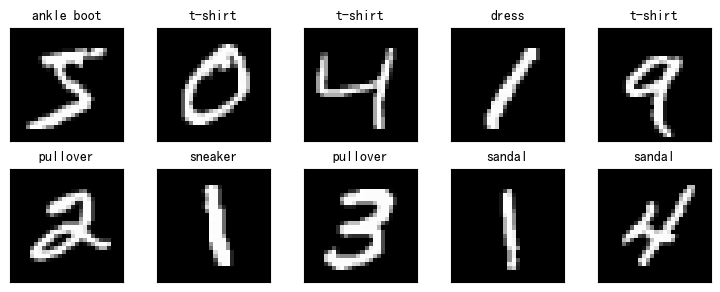

In [20]:
# 从训练集取前 10 张图片和对应标签
X, y = next(iter(data.DataLoader(mnist_train, batch_size=10)))

# 调用上面定义的两个函数进行可视化
show_images(
    X,                                        # 10 张图片张量
    num_rows=2, num_cols=5,                   # 2行5列网格
    titles=get_fashion_mnist_labels(y),       # 把数字标签转成文本
    scale=1.5
);


## Fashion-MNIST 样本索引解析

- `mnist_train`：Fashion-MNIST 训练集，每个样本是一个元组 `(图像, 标签)`。
- `mnist_train[0]`：取出第一个样本，返回 `(图像张量, 标签整数)`。
- `mnist_train[0][0]`：第一个样本的图像张量。
  - 形状：`(1, 28, 28)`  
  - `1`：单通道（灰度图）  
  - `28`：图像高度（像素）  
  - `28`：图像宽度（像素）
- 原因：`transforms.ToTensor()` 将 PIL 图像转为 PyTorch 张量，并自动添加通道维度。
- 像素值：由 0~255 整数缩放为 0~1 的 32 位浮点数。
- 若需获取标签：使用 `mnist_train[0][1]`，得到类别编号（0~9 的整数）。

In [21]:
print(mnist_train[0][0].shape)

torch.Size([1, 28, 28])


## 数据加载器与计时

- `batch_size`：每个批次的样本数量，这里设为 256。
- `DataLoader`：PyTorch 数据加载器，将数据集封装为可迭代对象，支持批量、打乱、多进程加载。
- `shuffle=True`：每个 epoch 开始时随机打乱数据顺序，防止模型记忆固定顺序。
- `num_workers`：数据加载使用的子进程数，设为 5 可并行读取，加快数据加载。
- `d2l.Timer`：计时器工具，用于测量代码执行时间。
- 遍历 `train_iter`：模拟遍历一次训练集的所有批次，统计读取时间。
- `timer.stop()`：停止计时并返回耗时，格式化为两位小数打印。

**关键点**  
- `num_workers` 不是越大越好，过多子进程会增加开销，一般设为 CPU 核心数附近，或从 4~8 开始尝试。  
- 数据加载速度会影响训练效率，合理设置 `batch_size` 和 `num_workers` 能有效利用硬件资源。

In [22]:
batch_size=256

def get_dataloader_workers():
    return 5
train_iter=data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=get_dataloader_workers())

timer = d2l.Timer()
for x,y in train_iter:
    continue
print(f'{timer.stop():.2f}sec')

4.27sec


In [23]:
# 把数据加载的完整流程封装成一个函数，方便后续复用
def load_data_fashion_mnist(batch_size, resize=None):
    "下载Fashion-MNIST数据集，然后加载到内存当中"
    trans = [transforms.ToTensor()]  # 先用列表存放变换操作
    if resize:                        # 如果指定了 resize，在列表最前面插入缩放操作
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)  # 将多个变换组合成一个流水线
    mnist_train = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=trans, download=True)
    mnist_test = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=trans, download=True)
    return (
        data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=get_dataloader_workers()),
        data.DataLoader(mnist_test, batch_size=batch_size, shuffle=False, num_workers=get_dataloader_workers())
    )
